### Code to look into the databases for the microkinetic model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
full_path = r"FINAL-Reizmann_AIMNet_Gtotal_msrrho_20C_120C_all_species_new_reduced_all_methods.csv"
df = pd.read_csv(full_path)

full_path_old = r"OLD-Reizmann_AIMNet_Gtotal_msrrho_20C_120C_all_species_new.csv"
df_old = pd.read_csv(full_path_old)

df_reactant9 = pd.read_csv(r"TM9_FINAL\TM9_FINAL\tables\TM9_Gtotal_msrrho_20C_120C_all_species_wide_kcalmol_plus8_species_plus5_SPE-FINAL.csv")

df_reactant8 = pd.read_csv(r"TM8_FINAL\TM8_FINAL\tables\TM8_Gtotal_msrrho_20C_120C_FINAL.csv")

df_BOH3 = pd.read_csv(r"BOH3_neutral_recalc\BOH3_neutral_recalc\tables\BOH3_Gtotal_msrrho_20C_120C_all_species_wide_kcalmol.csv")

In [4]:
df['species_class'].unique()

array(['BOH2Ar', 'BPinAr', 'solution_base_species', 'L', 'OA_TS',
       'OA_product', 'OA_reactant', 'PdL2', 'PdLArOH', 'PdL', 'Pinacol',
       'Substrate', 'TM_TS', 'TM_product', 'TM_reactant',
       'TM_reactant_10'], dtype=object)

In [5]:
len(df['species_class'].unique())

16

In [6]:
df['species_name'].unique()

array(['BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid',
       'BOH2Ar_compound_6_benzofuran-2-boronic_acid',
       'BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boronic_acid',
       'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate',
       'BPinAr_compound_6_benzofuran-2-boronate',
       'BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boronate', 'Br_minus',
       'Cl_minus', 'DBUH_Br_thf', 'DBUH_Cl_thf', 'DBUH_plus_thf',
       'DBU_thf', 'H2O', 'HBr', 'HCl', 'L_Mono_AmPhos',
       'L_Mono_Catacxium_A', 'L_Mono_PCy3', 'L_Mono_PPh3', 'L_Mono_PoTol',
       'L_Mono_RuPhos', 'L_Mono_SPhos', 'L_Mono_XPhos', 'L_Mono_tBu3',
       'L_Xantphos_Xantphos', 'OA_TS_2_chloropyridine_Displaced_AmPhos',
       'OA_TS_2_chloropyridine_Displaced_Catacxium_A',
       'OA_TS_2_chloropyridine_Displaced_PCy3',
       'OA_TS_2_chloropyridine_Displaced_PPh3',
       'OA_TS_2_chloropyridine_Displaced_PoTol',
       'OA_TS_2_chloropyridine_Displaced_RuPhos',
       'OA_TS_2_chloropyrid

### Settings

In [7]:
# Unless otherwise defined, these are the settings used for testing the barriers
substrate = "3_bromoquinoline"   # case1 substrate
ligand    = "PCy3"               # ligand
T         = 110               # temperature in Celsius
case      = "case1"
ligand_list = ["PCy3", "PPh3", "AmPhos", "Catacxium_A", "RuPhos", "SPhos", "tBu3", "XPhos"]
substrate_list = ["3_bromoquinoline", "2_chloropyridine", "3_chloropyridine"]
temperature_list = [30, 50, 70, 90, 110]
case_list = ["case1", "case2", "case3", "case4"]
dict_tm_case = {
    'case1': ('3_bromoquinoline', 'BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid', 'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate'),
    'case2': ('3_chloropyridine', 'BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid', 'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate'),
    'case3': ('3_chloropyridine', 'BOH2Ar_compound_6_benzofuran-2-boronic_acid', 'BPinAr_compound_6_benzofuran-2-boronate'),
    'case4': ('2_chloropyridine', 'BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boronic_acid', 'BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boronate'),
}

### Functions

In [8]:
# Helper: look up G for a species at a given temperature
def get_G(df, species_name, temperature_C):
    row = df[(df["species_name"] == species_name) & (df["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol"].values[0] 

def get_G_old(df_old, species_name, temperature_C):
    row = df_old[(df_old["species_name"] == species_name) & (df_old["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["G_total_AIMNet_msrrho_kcal_mol"].values[0] # Before: G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol

def get_G_reactant9(df_reactant9, species_name, temperature_C):
    row = df_reactant9[(df_reactant9["species"] == species_name) & (df_reactant9["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["Gtotal_wB97MV_gas_SPE_AIMNet2PD_msRRHO_Gsolv_THF_kcal_mol"].values[0]

def get_G_reactant8(df_reactant8, species_name, temperature_C):
    row = df_reactant8[(df_reactant8["species"] == species_name) & (df_reactant8["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["Gtotal_wB97MV_gas_SPE_AIMNet2PD_msRRHO_Gsolv_THF_kcal_mol"].values[0] # Before: G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol

def get_G_BOH3(df_BOH3, species_name, temperature_C):
    row = df_BOH3[(df_BOH3["species"] == species_name) & (df_BOH3["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["Gtotal_wB97MV_gas_SPE_AIMNet2PD_msRRHO_Gsolv_THF_kcal_mol"].values[0] 

# Plotting function for the OA
def plotting_OA_barriers(substrate, ligand, T, scenario="Scenario_2"):
    results_ligand = OA_barriers(substrate, ligand, T)
    labels   = ["PdL2 + Sub\n(resting)", "OA_reactant\n+ L", "OA_TS\n+ L", "OA_product\n+ L"]
    energies = [0.0, results_ligand[scenario]["dG_OA_reactant"], results_ligand[scenario]["dG_OA_TS"], results_ligand[scenario]["dG_OA_product"]]
    x = [0, 1, 2, 3]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, energies, "o-", color="steelblue", linewidth=2, markersize=8)
    for xi, yi, lbl in zip(x, energies, labels):
        ax.annotate(f"{lbl}\n{yi:+.1f} kcal/mol", (xi, yi),
                    textcoords="offset points", xytext=(0, 14),
                    ha="center", fontsize=8.5)
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(["PdL2+Sub", "OA_react+L", "OA_TS+L", "OA_prod+L"], fontsize=9)
    ax.set_ylabel("dG (kcal/mol)")
    ax.set_ylim(min(energies)-5, max(energies)+10)
    ax.set_title(f"OA Energy Profile {scenario}: {substrate} / {ligand} @ {T} C")
    plt.tight_layout()
    plt.show()

def plotting_TM_barriers(ligand, case, T, scenario="Scenario_2"):
    substrate = dict_tm_case[case][0]
    results_ligand = TM_barriers(ligand, case, T)
    if scenario == "Scenario_1":
       labels_tm   = ["PdLArOH + BOH2Ar\n(ref)", "TM_reactant_10", "TM_reactant", "TM_TS", "TM_product\n+ BOH3"]
       energies_tm = [0.0, results_ligand[scenario]["dG_TM_reactant_10"], results_ligand[scenario]["dG_TM_reactant"], results_ligand[scenario]["dG_TM_TS"], results_ligand[scenario]["dG_TM_product"]]
       x = [0, 1, 2, 3, 4]

       fig, ax = plt.subplots(figsize=(8, 4))
       ax.plot(x, energies_tm, "o-", color="darkorange", linewidth=2, markersize=8)
       for xi, yi, lbl in zip(x, energies_tm, labels_tm):
            ax.annotate(f"{lbl}\n{yi:+.1f}", (xi, yi),
                        textcoords="offset points", xytext=(0, 14), ha="center", fontsize=8.5)
       ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
       ax.set_xticks(x)
       ax.set_xticklabels(labels_tm, fontsize=9)
       ax.set_ylabel("dG (kcal/mol)")
       ax.set_ylim(min(energies_tm)-5, max(energies_tm)+5)
       ax.set_title(f"TM Energy Profile: {case} / {ligand} @ {T} C")
       plt.tight_layout()
       plt.show()
 
    else:
        labels   = ["PdLArOH + BPin + 2H2O\n(ref)", "TM_reactant\n+ pinacol", "TM_TS\n+ pinacol", "TM_prod\n+ pinacol + B(OH)3"]
        energies = [0.0, results_ligand[scenario]["dG_TM_reactant"], results_ligand[scenario]["dG_TM_TS"], results_ligand[scenario]["dG_TM_product"]]
        x = [0, 1, 2, 3]

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(x, energies, "o-", color="steelblue", linewidth=2, markersize=8)
        for xi, yi, lbl in zip(x, energies, labels):
            ax.annotate(f"{lbl}\n{yi:+.1f} kcal/mol", (xi, yi),
                        textcoords="offset points", xytext=(0, 14),
                        ha="center", fontsize=8.5)
        ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(["PdLArOH+BPin+2H2O", "TM_react+pinacol", "TM_TS+pinacol", "TM_prod+pinacol+B(OH)3"], fontsize=9)
        ax.set_ylabel("dG (kcal/mol)")
        ax.set_ylim(min(energies)-5, max(energies)+10)
        ax.set_title(f"TM Energy Profile {scenario}: {substrate} / {ligand} @ {T} C ({case})")
        plt.tight_layout()
        plt.show()

def plotting_TM_barriers_with_react9(ligand, case, T, scenario="Scenario_2"):
    substrate = dict_tm_case[case][0]
    results_ligand = TM_barriers_with_react9(ligand, case, T)
    if scenario == "Scenario_1":
       labels_tm   = ["TM_reactant8 + \n 2 x R2B(OH)2", "TM_reactant_9", "TM_reactant_10", "TM_reactant", "TM_TS", "TM_product\n+ BOH3"]
       energies_tm = [0.0, results_ligand[scenario]["dG_TM_reactant_9"], results_ligand[scenario]["dG_TM_reactant_10"], results_ligand[scenario]["dG_TM_reactant"], results_ligand[scenario]["dG_TM_TS"], results_ligand[scenario]["dG_TM_product"]]
       x = [0, 1, 2, 3, 4, 5]

       fig, ax = plt.subplots(figsize=(8, 4))
       ax.plot(x, energies_tm, "o-", color="darkorange", linewidth=2, markersize=8)
       for xi, yi, lbl in zip(x, energies_tm, labels_tm):
            ax.annotate(f"{lbl}\n{yi:+.1f}", (xi, yi),
                        textcoords="offset points", xytext=(0, 14), ha="center", fontsize=8.5)
       ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
       ax.set_xticks(x)
       ax.set_xticklabels(labels_tm, fontsize=9)
       ax.set_ylabel("dG (kcal/mol)")
       ax.set_ylim(min(energies_tm)-5, max(energies_tm)+5)
       ax.set_title(f"TM Energy Profile: {case} / {ligand} @ {T} C")
       plt.tight_layout()
       plt.show()
 
    else:
        labels   = ["PdLArOH + BPin + 2H2O\n(ref)", "TM_reactant\n+ pinacol", "TM_TS\n+ pinacol", "TM_prod\n+ pinacol + B(OH)3"]
        energies = [0.0, results_ligand[scenario]["dG_TM_reactant"], results_ligand[scenario]["dG_TM_TS"], results_ligand[scenario]["dG_TM_product"]]
        x = [0, 1, 2, 3]

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(x, energies, "o-", color="steelblue", linewidth=2, markersize=8)
        for xi, yi, lbl in zip(x, energies, labels):
            ax.annotate(f"{lbl}\n{yi:+.1f} kcal/mol", (xi, yi),
                        textcoords="offset points", xytext=(0, 14),
                        ha="center", fontsize=8.5)
        ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(["PdLArOH+BPin+2H2O", "TM_react+pinacol", "TM_TS+pinacol", "TM_prod+pinacol+B(OH)3"], fontsize=9)
        ax.set_ylabel("dG (kcal/mol)")
        ax.set_ylim(min(energies)-5, max(energies)+10)
        ax.set_title(f"TM Energy Profile {scenario}: {substrate} / {ligand} @ {T} C ({case})")
        plt.tight_layout()
        plt.show()

## Transmetalation (TM) Barrier Calculation

| Scenario | Reference state | Reaction |
|---|---|---|
| PdLArOH path | PdLArOH + B(OH)2Ar | `PdLArOH + B(OH)2Ar --> TM_reactant_10 --> TM_reactant --> TM_TS --> TM_product + B(OH)3-` |
| BPin direct path | PdLArOH + BPin + 2H2O | `"PdLArOH + BPin + 2H2O", "TM_reactant_TEST + pinacol", "TM_TS_TEST + pinacol", "TM_prod_TEST + pinacol + B(OH)3"` |


In [9]:
def TM_barriers(ligand, case, T, verbose=False):
    substrate = dict_tm_case[case][0]
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine_concerted"
    else:
        substrate_capitalized = substrate 

    # Fetch free energies
    G_PdLArOH  = get_G(df, f"PdLArOH_{substrate}_{ligand}",  T)
    G_BOH2Ar   = get_G(df, dict_tm_case[case][1],             T)
    G_BOH3     = get_G_old(df_old, "BOH3_minus", T)
    G_TM_react_10 = get_G(df, f"TM_reactant_{case}_{ligand}_as_10",    T)
    G_TM_react = get_G(df, f"TM_reactant_{case}_{ligand}",    T)
    G_TM_TS    = get_G(df, f"TM_TS_{case}_{ligand}",          T)
    G_TM_prod  = get_G(df, f"TM_product_{case}_{ligand}",     T)
    G_Bpin = get_G(df, dict_tm_case[case][2], T)
    G_H2O = get_G(df, "H2O", T)
    G_pinacol = get_G(df, "Pinacol", T)

    # Reference states
    G_ref_TM_sc1 = G_PdLArOH + G_BOH2Ar
    G_ref_TM_sc2 = G_PdLArOH + G_Bpin + 2*G_H2O

    # Scenario 1: TM_reactant_10 as pre-complex (ref = PdLArOH + BOH2Ar)
    dG_TM_react_10_sc1 = G_TM_react_10      - G_ref_TM_sc1
    dG_TM_react_sc1 = G_TM_react            - G_ref_TM_sc1
    dG_TM_TS_sc1    = G_TM_TS               - G_ref_TM_sc1
    dG_TM_prod_sc1  = (G_TM_prod + G_BOH3)  - G_ref_TM_sc1
    total_barrier_sc1 = max(dG_TM_TS_sc1, dG_TM_TS_sc1 - dG_TM_react_sc1, dG_TM_TS_sc1 - dG_TM_react_10_sc1)

    # Scenario 2: Bpin route, where the reference state is PdLArOH + BPin + 2 H2O
    dG_TM_react_sc2 = (G_TM_react + G_pinacol) - G_ref_TM_sc2
    dG_TM_TS_sc2    = (G_TM_TS + G_pinacol)    - G_ref_TM_sc2
    dG_TM_prod_sc2  = (G_TM_prod + G_pinacol + G_BOH3) - G_ref_TM_sc2
    total_barrier_sc2 = max(dG_TM_TS_sc2, dG_TM_TS_sc2 - dG_TM_react_sc2)

    if verbose == True:
        print(f"TM Barrier Calculation: {substrate} / {ligand} @ {T} C")
        print("=" * 60)
        print()
        print("Scenario 1: TM_reactant_10 as pre-complex (ref = PdLArOH + BOH2Ar):")
        print(f"  dG(TM_reactant_10) : {dG_TM_react_10_sc1:+.2f} kcal/mol")
        print(f"  dG(TM_reactant) : {dG_TM_react_sc1:+.2f} kcal/mol")
        print(f"  dG(TM_TS)       : {dG_TM_TS_sc1:+.2f} kcal/mol")
        print(f"  dG(TM_product)  : {dG_TM_prod_sc1:+.2f} kcal/mol")
        print(f"  Total barrier (max of TS or TS - reactant): {total_barrier_sc1:+.2f} kcal/mol")
        print()
        print("Scenario 2: Bpin route (ref = PdLArOH + BPin + 2 H2O):")
        print(f"  dG(TM_reactant) : {dG_TM_react_sc2:+.2f} kcal/mol")
        print(f"  dG(TM_TS)       : {dG_TM_TS_sc2:+.2f} kcal/mol")
        print(f"  dG(TM_product)  : {dG_TM_prod_sc2:+.2f} kcal/mol")
        print(f"  Total barrier (max of TS or TS - reactant): {total_barrier_sc2:+.2f} kcal/mol")

    return {
            "Scenario_1": {
                "dG_TM_reactant_10": dG_TM_react_10_sc1,
                "dG_TM_reactant": dG_TM_react_sc1,
                "dG_TM_TS": dG_TM_TS_sc1,
                "dG_TM_product": dG_TM_prod_sc1,
                'total_barrier': total_barrier_sc1
            },
            "Scenario_2": {
                "dG_TM_reactant": dG_TM_react_sc2,
                "dG_TM_TS": dG_TM_TS_sc2,
                "dG_TM_product": dG_TM_prod_sc2,
                'total_barrier': total_barrier_sc2
            }
        }

In [12]:
# TM_barriers(substrate, ligand, T)
results_all_ligands_TM = {(ligand, case): TM_barriers(ligand, case, T) for ligand in ligand_list for case in case_list}

In [13]:
# Code that iterates over all temperatures, substrates, ligands, and cases, collects the TM barriers for both scenarios, and stores them in a DataFrame for further analysis or plotting
df_TM_barriers = pd.DataFrame()

rows = []

for temperature in temperature_list:
    results_all_ligands_TM = {(ligand, case): TM_barriers(ligand, case, temperature) for ligand in ligand_list for substrate in substrate_list for case in case_list}
    print(f"\nCompleted TM barrier calculations for T = {temperature} C")
    for (ligand, case), results in results_all_ligands_TM.items():
        print(f"\n=== {dict_tm_case[case][0]} / {ligand} @ {temperature} C ===")
        print("Scenario 1: PdL resting state (ref = PdL + Sub):")
        print(f"  Total barrier (max of TS or TS - reactant): {results['Scenario_1']['total_barrier']:+.2f} kcal/mol")
        print("Scenario 2: PdL2 resting state (ref = PdL2 + Sub, L released):")
        print(f"  Total barrier (max of TS or TS - reactant): {results['Scenario_2']['total_barrier']:+.2f} kcal/mol")
        rows.append({
            "temp_C": temperature,
            "substrate": dict_tm_case[case][0],
            "boron species (BOH2)": dict_tm_case[case][1],
            "boron species (BPin)": dict_tm_case[case][2],
            "ligand": ligand,
            "case": case,
            "TM_barrier_scenario_1": results['Scenario_1']['total_barrier'],
            "TM_barrier_scenario_2": results['Scenario_2']['total_barrier']
        })

df_TM_barriers = pd.concat([df_TM_barriers, pd.DataFrame(rows)], ignore_index=True)


Completed TM barrier calculations for T = 30 C

=== 3_bromoquinoline / PCy3 @ 30 C ===
Scenario 1: PdL resting state (ref = PdL + Sub):
  Total barrier (max of TS or TS - reactant): +11.38 kcal/mol
Scenario 2: PdL2 resting state (ref = PdL2 + Sub, L released):
  Total barrier (max of TS or TS - reactant): +12.11 kcal/mol

=== 3_chloropyridine / PCy3 @ 30 C ===
Scenario 1: PdL resting state (ref = PdL + Sub):
  Total barrier (max of TS or TS - reactant): +12.11 kcal/mol
Scenario 2: PdL2 resting state (ref = PdL2 + Sub, L released):
  Total barrier (max of TS or TS - reactant): +14.89 kcal/mol

=== 3_chloropyridine / PCy3 @ 30 C ===
Scenario 1: PdL resting state (ref = PdL + Sub):
  Total barrier (max of TS or TS - reactant): +14.17 kcal/mol
Scenario 2: PdL2 resting state (ref = PdL2 + Sub, L released):
  Total barrier (max of TS or TS - reactant): +12.11 kcal/mol

=== 2_chloropyridine / PCy3 @ 30 C ===
Scenario 1: PdL resting state (ref = PdL + Sub):
  Total barrier (max of TS or TS - 

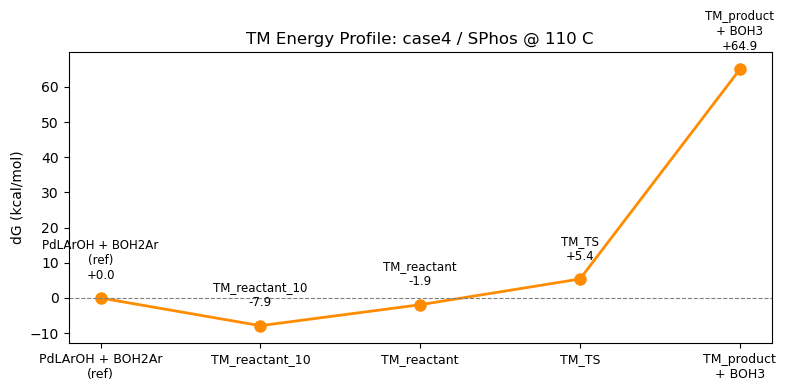

In [ ]:
# Note: Here the TM_product lays way higher as the TS, due to the BOH3 that is included here. This BOH3 species was calculated with an older method, and thus the absolute values are not correct. This however, doesn't have any effect on the barrier that comes before that.
plotting_TM_barriers(ligand="SPhos", case="case4", T=110, scenario="Scenario_1")